# Projet Bloc 5

**Projet Doument AI d'extraction d'informations dans des devis photovoltaïques**

## Objectifs du notebook

Le notebook couvre  les parties suivantes:

1. chargement du dataset et de ses labels ;
2. split par document en train, validation et test ;
3. fine-tuning de LayoutLMv3 ;
4. fine-tuning de LiLT ;
5. analyse des courbes d'apprentissage ;
6. évaluation finale sur le test isolé ;
7. comparaison et sélection du modèle de référence.



## Imports des librairies


In [21]:
import csv
import json
import random
from collections import Counter, defaultdict
from pathlib import Path
from typing import Any
from IPython.display import display
from PIL import Image

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from datasets import Dataset, load_from_disk


from seqeval.metrics import accuracy_score, f1_score, precision_score, recall_score
from transformers import (
    AutoProcessor,
    AutoTokenizer,
    LayoutLMv3ForTokenClassification,
    LayoutLMv3Processor,
    LiltForTokenClassification,
    Trainer,
    TrainingArguments,
)


## Paramètres et prérequis

Le notebook doit être exécuté depuis la racine du projet `document-intelligence-engine`.

Le dataset créé lors de l'étape précédente doit être disponible dans les répertoires suivantes:

```text
dataset/processed/layoutlm_full/dataset
dataset/processed/layoutlm_full/labels.json
```



In [7]:
RUN_LAYOUTLMV3_TRAINING = False
RUN_LILT_TRAINING = False
RUN_FINAL_TEST_EVALUATION = False

LAYOUTLMV3_LEARNING_RATE = 5e-5
NUM_EPOCHS = 10


## Fonctions utilitaires de visualisation

In [22]:
def charger_historique_entrainement(csv_path: str | Path) -> pd.DataFrame:
    # Charge et contrôle un historique d'entraînement sauvegardé en CSV.
    path = Path(csv_path)
    if not path.exists():
        raise FileNotFoundError(f"Fichier de métriques introuvable : {path}")

    history = pd.read_csv(path)
    required_columns = {"epoch", "train_loss", "eval_loss", "f1"}
    missing = required_columns.difference(history.columns)
    if missing:
        raise ValueError(f"Colonnes manquantes dans {path.name} : {sorted(missing)}")
    return history.sort_values("epoch").reset_index(drop=True)


def visualiser_entrainement(history: pd.DataFrame, model_name: str) -> None:
    # Affiche le F1-score et les losses d'entraînement/validation.
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

    axes[0].plot(history["epoch"], history["f1"], marker="o", linewidth=2)
    best_index = history["f1"].idxmax()
    best_epoch = history.loc[best_index, "epoch"]
    best_f1 = history.loc[best_index, "f1"]
    axes[0].scatter(best_epoch, best_f1, s=90, zorder=3, label=f"Meilleur F1 : {best_f1:.3f}")
    axes[0].set(title=f"{model_name} — F1 validation", xlabel="Époque", ylabel="F1")
    axes[0].set_ylim(0, 1)
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    axes[1].plot(history["epoch"], history["train_loss"], marker="o", label="Train")
    axes[1].plot(history["epoch"], history["eval_loss"], marker="o", label="Validation")
    axes[1].set(title=f"{model_name} — évolution de la loss", xlabel="Époque", ylabel="Loss")
    axes[1].grid(alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def afficher_meilleure_epoque(history: pd.DataFrame, model_name: str) -> pd.DataFrame:
    # Retourne la ligne correspondant au meilleur F1 de validation.
    best_row = history.loc[[history["f1"].idxmax()]].copy()
    best_row.insert(0, "model", model_name)
    display(best_row)
    return best_row


## Fine-tuning de LayoutLMv3

LayoutLMv3 exploite trois modalités : le texte, la position des tokens et l'image de la page. Le checkpoint pré-entraîné est spécialisé sur onze classes BIO : cinq entités avec labels `B`/`I`, plus la classe `O`.

### Paramètres de configuration de LayoutLMv3

In [ ]:

PROJECT_ROOT = (
    Path.cwd().parent
    if Path.cwd().name == "notebooks"
    else Path.cwd()
)
DATASET_DIR = (PROJECT_ROOT / "dataset"/ "processed"/ "layoutlm_full"/ "dataset")
LABELS_DIR = (PROJECT_ROOT / "dataset"/ "processed"/ "layoutlm_full"/ "labels.json")
LABELS_PATH = Path(LABELS_DIR)
OUTPUT_DIR = Path(
    "models/layoutlmv3-photovoltaic-full-split-70-15-15"
)
FINAL_MODEL_DIR = OUTPUT_DIR / "final"
METRICS_CSV_PATH = OUTPUT_DIR / "training_metrics.csv"
MAX_LENGTH = 512
TRAIN_RATIO = 0.70
VALIDATION_RATIO = 0.15
TEST_RATIO = 0.15
SEED = 42
EPOCH = NUM_EPOCHS

### Fonctions utilitaires de chargement des labels, encodage multimodal et split par document

Le split se fait au niveau **document**, et non au niveau page, afin d'éviter qu'un même devis apparaisse dans plusieurs ensembles.

In [23]:
# Fonction qui charge depuis un fichier JSON les correspondances entre les 
# nom et les identifiants numériques utilisés par le modèle
def load_labels() -> tuple[dict[str, int], dict[int, str]]:
    with LABELS_DIR.open("r", encoding="utf-8") as file:
        payload = json.load(file)

    label2id = {
        label: int(label_id)
        for label, label_id in payload["label2id"].items()
    }
    id2label = {
        int(label_id): label
        for label_id, label in payload["id2label"].items()
    }
    return label2id, id2label


# Fonction qui transorme les données bruts du dataset en données numériques utilisable
# par le modèle. La tranformation se fait par le processor du modèle LayoutLmv3. 
# Ce processor traite les 3 types de données (texte, position et image)
# Convertit chaque page annotée eb ebtrée multimodale pour LayoutLMV3.
# Elle renvoie un dictionnaire
def encode_layoutlmv3_example(
    example: dict[str, Any],
    processor: LayoutLMv3Processor,
) -> dict[str, Any]:

    image_path = Path(example["image_path"])

    # Les chemins du dataset sont relatifs à la racine du projet.
    if not image_path.is_absolute():
        image_path = PROJECT_ROOT / image_path

    if not image_path.exists():
        raise FileNotFoundError(
            f"Image introuvable : {image_path.resolve()}"
        )

    with Image.open(image_path) as source_image:
        # LayoutLMv3 attend une image RGB composée de trois canaux.
        image = source_image.convert("RGB")

    encoding = processor(
        image,
        example["tokens"],
        boxes=example["bboxes"],
        word_labels=example["ner_tags"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
    )

    return {
        "input_ids": encoding["input_ids"],
        "attention_mask": encoding["attention_mask"],
        "bbox": encoding["bbox"],
        "labels": encoding["labels"],
        "pixel_values": encoding["pixel_values"][0],
    }

# Parcours le dataset avec la méthode map de hugging fae et applique encode_exemple
# à chaque page 
def encode_layoutlmv3_dataset(dataset: Dataset, processor: LayoutLMv3Processor) -> Dataset:
    return dataset.map(
        lambda example: encode_layoutlmv3_example(example, processor),
        remove_columns=dataset.column_names,
        desc="Encodage",
    )

# fonction qui sert à découper le dataset en 3 sous ensembles
# de donnée de train/test/validation
def split_by_document(
    dataset: Dataset,
    train_ratio: float = TRAIN_RATIO,
    validation_ratio: float = VALIDATION_RATIO,
    test_ratio: float = TEST_RATIO,
    seed: int = SEED,
) -> tuple[Dataset, Dataset, Dataset]:
    ratio_sum = train_ratio + validation_ratio + test_ratio

    if abs(ratio_sum - 1.0) > 1e-9:
        raise ValueError(
            "La somme des ratios train, validation et test "
            f"doit être égale à 1.0, reçu : {ratio_sum}"
        )

    if min(train_ratio, validation_ratio, test_ratio) <= 0:
        raise ValueError(
            "Les ratios doivent être strictement positifs."
        )

    documents: dict[str, list[int]] = defaultdict(list)

    for index, example in enumerate(dataset):
        document_id = example["id"].rsplit("_page_", 1)[0]
        documents[document_id].append(index)

    document_ids = sorted(documents.keys())

    if len(document_ids) < 3:
        raise ValueError(
            "Le dataset doit contenir au moins trois documents."
        )

    random.Random(seed).shuffle(document_ids)

    document_count = len(document_ids)
    train_end = int(document_count * train_ratio)
    validation_end = train_end + int(
        document_count * validation_ratio
    )

    train_docs = set(document_ids[:train_end])
    validation_docs = set(
        document_ids[train_end:validation_end]
    )
    test_docs = set(document_ids[validation_end:])

    if not train_docs or not validation_docs or not test_docs:
        raise ValueError(
            "Au moins un des splits train, validation ou test est vide."
        )

    train_indices = [
        index
        for document_id, indices in documents.items()
        if document_id in train_docs
        for index in indices
    ]
    validation_indices = [
        index
        for document_id, indices in documents.items()
        if document_id in validation_docs
        for index in indices
    ]
    test_indices = [
        index
        for document_id, indices in documents.items()
        if document_id in test_docs
        for index in indices
    ]

    train_dataset = dataset.select(train_indices)
    validation_dataset = dataset.select(validation_indices)
    test_dataset = dataset.select(test_indices)

    if not train_docs.isdisjoint(validation_docs):
        raise ValueError("Fuite de documents entre train et validation.")
    if not train_docs.isdisjoint(test_docs):
        raise ValueError("Fuite de documents entre train et test.")
    if not validation_docs.isdisjoint(test_docs):
        raise ValueError("Fuite de documents entre validation et test.")

    if len(train_docs | validation_docs | test_docs) != document_count:
        raise ValueError("Tous les documents n'ont pas été répartis.")

    if (
        len(train_dataset)
        + len(validation_dataset)
        + len(test_dataset)
        != len(dataset)
    ):
        raise ValueError("Toutes les pages n'ont pas été réparties.")

    print("\n===== Split par devis =====")
    print(f"Documents train      : {len(train_docs)}")
    print(f"Documents validation : {len(validation_docs)}")
    print(f"Documents test       : {len(test_docs)}")
    print(f"Pages train          : {len(train_dataset)}")
    print(f"Pages validation     : {len(validation_dataset)}")
    print(f"Pages test           : {len(test_dataset)}")

    return train_dataset, validation_dataset, test_dataset


### Fonctions dédiées à la surcharge du Trainer de HuggingFace et autres fonctions d'affichage

La classe `O` est très majoritaire. Des poids de classes sont donc calculés pour augmenter l'importance des entités rares dans la fonction de perte. Le F1-score est utilisé comme métrique principale.

In [24]:
def print_raw_label_distribution(dataset: Dataset, id2label: dict[int, str]) -> None:
    counts: Counter[int] = Counter()
    for example in dataset:
        counts.update(example["ner_tags"])

    print("\n===== Distribution des labels dans le dataset brut =====")
    for label_id, label in id2label.items():
        print(f"{label:<25} : {counts.get(label_id, 0)}")

def print_encoded_label_distribution(
    dataset: Dataset,
    id2label: dict[int, str],
    dataset_name: str,
) -> None:
    counts: Counter[int] = Counter()

    for example in dataset:
        counts.update(
            int(label_id)
            for label_id in example["labels"]
            if label_id != -100
        )

    print(f"\n===== Distribution des labels après encodage : {dataset_name} =====")
    for label_id, label in id2label.items():
        print(f"{label:<25} : {counts.get(label_id, 0)}")

# Calcule le poids pour chaque classe en fonction de sa fréquence.
# PErmet de réduire l'impact du déséquilibre des classes, surtout du label 0
# On ignore le token special -100
# Objectif est de minimiser les tokens hors labels.
# Utilisé par la fonction de perte afin de limiter le biais du modèle 
# Utilisé uniqment pour le train dataset
def compute_class_weights(dataset: Dataset, num_labels: int) -> torch.Tensor:
    counts: Counter[int] = Counter()

    for example in dataset:
        counts.update(
            int(label_id)
            for label_id in example["labels"]
            if label_id != -100
        )

    total = sum(counts.values())
    weights = [
        total / (num_labels * max(counts.get(label_id, 0), 1))
        for label_id in range(num_labels)
    ]
    return torch.tensor(weights, dtype=torch.float)

# contruit la la fonction d'évaluation utilisée par le Trainer de HugginFace.
# Calcul la précision, le rappel, le F1 score et l'accuracy
def build_compute_metrics(id2label: dict[int, str]):
    def compute_metrics(eval_prediction):
        logits, labels = eval_prediction
        predicted_ids = np.argmax(logits, axis=-1)

        true_predictions: list[list[str]] = []
        true_labels: list[list[str]] = []

        for prediction_sequence, label_sequence in zip(predicted_ids, labels):
            current_predictions: list[str] = []
            current_labels: list[str] = []

            for predicted_id, label_id in zip(prediction_sequence, label_sequence):
                if label_id == -100:
                    continue

                current_predictions.append(id2label[int(predicted_id)])
                current_labels.append(id2label[int(label_id)])

            true_predictions.append(current_predictions)
            true_labels.append(current_labels)

        predicted_distribution = Counter(
            label
            for sequence in true_predictions
            for label in sequence
        )
        real_distribution = Counter(
            label
            for sequence in true_labels
            for label in sequence
        )

        print("\n===== Distribution des labels réels en validation =====")
        for label in id2label.values():
            print(f"{label:<25} : {real_distribution.get(label, 0)}")

        print("\n===== Distribution des labels prédits en validation =====")
        for label in id2label.values():
            print(f"{label:<25} : {predicted_distribution.get(label, 0)}")

        return {
            "precision": precision_score(
                true_labels,
                true_predictions,
                zero_division=0,
            ),
            "recall": recall_score(
                true_labels,
                true_predictions,
                zero_division=0,
            ),
            "f1": f1_score(
                true_labels,
                true_predictions,
                zero_division=0,
            ),
            "accuracy": accuracy_score(true_labels, true_predictions),
        }

    return compute_metrics

# Classe qui herite du Trainer de HugginFace et remplace la fonction de loss
# On utilise cette nouvelle fonction de loss pour réduire l'influence de 
# la classe majoritaire 0
# Le Trainer par défaut ne prend pas en compte les dataset déséquilibrés.
class WeightedTrainer(Trainer):
    def __init__(self, class_weights: torch.Tensor, **kwargs) -> None:
        super().__init__(**kwargs)
        self.class_weights = class_weights

    def compute_loss(
        self,
        model,
        inputs,
        return_outputs: bool = False,
        **kwargs,
    ):
        model_inputs = inputs.copy()
        labels = model_inputs.pop("labels")
        outputs = model(**model_inputs)
        logits = outputs.logits

        loss_function = nn.CrossEntropyLoss(
            weight=self.class_weights.to(logits.device),
            ignore_index=-100,
        )
        loss = loss_function(
            logits.reshape(-1, model.config.num_labels),
            labels.reshape(-1),
        )

        return (loss, outputs) if return_outputs else loss


### Fonctions de métriques d'évaluation

In [25]:
def build_epoch_metrics(log_history: list[dict[str, Any]]) -> list[dict[str, float]]:
    """Construit une ligne par évaluation/époque depuis Trainer.state.log_history."""
    rows: list[dict[str, float]] = []
    latest_train_loss: float | None = None
    latest_learning_rate: float | None = None

    for entry in log_history:
        if "loss" in entry:
            latest_train_loss = float(entry["loss"])
        if "learning_rate" in entry:
            latest_learning_rate = float(entry["learning_rate"])

        if "eval_loss" not in entry:
            continue

        rows.append(
            {
                "epoch": float(entry.get("epoch", len(rows) + 1)),
                "train_loss": latest_train_loss if latest_train_loss is not None else float("nan"),
                "eval_loss": float(entry["eval_loss"]),
                "precision": float(entry.get("eval_precision", 0.0)),
                "recall": float(entry.get("eval_recall", 0.0)),
                "f1": float(entry.get("eval_f1", 0.0)),
                "accuracy": float(entry.get("eval_accuracy", 0.0)),
                "learning_rate": (
                    latest_learning_rate
                    if latest_learning_rate is not None
                    else float("nan")
                ),
            }
        )

    return rows

def print_metrics_table(rows: list[dict[str, float]]) -> None:
    if not rows:
        print("\nAucune métrique d'évaluation trouvée.")
        return

    headers = [
        "Epoch",
        "Train loss",
        "Eval loss",
        "Precision",
        "Recall",
        "F1",
        "Accuracy",
        "Learning rate",
    ]
    widths = [7, 12, 11, 11, 9, 9, 10, 14]

    def format_row(values: list[str]) -> str:
        return " | ".join(
            value.rjust(width)
            for value, width in zip(values, widths)
        )

    print("\n===== Tableau récapitulatif des métriques =====")
    print(format_row(headers))
    print("-+-".join("-" * width for width in widths))

    for row in rows:
        print(
            format_row(
                [
                    f"{row['epoch']:.0f}",
                    f"{row['train_loss']:.4f}",
                    f"{row['eval_loss']:.4f}",
                    f"{row['precision']:.4f}",
                    f"{row['recall']:.4f}",
                    f"{row['f1']:.4f}",
                    f"{row['accuracy']:.4f}",
                    f"{row['learning_rate']:.2e}",
                ]
            )
        )

def save_metrics_csv(rows: list[dict[str, float]], path: Path) -> None:
    if not rows:
        return

    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8", newline="") as file:
        writer = csv.DictWriter(file, fieldnames=list(rows[0].keys()))
        writer.writeheader()
        writer.writerows(rows)

    print(f"Métriques sauvegardées dans : {path}")



### Chargement du dataset et analyse du dataset

In [26]:
dataset = load_from_disk(str(DATASET_DIR))
label2id, id2label = load_labels()

print_raw_label_distribution(dataset, id2label)


===== Distribution des labels dans le dataset brut =====
O                         : 51025
B-CLIENT                  : 142
I-CLIENT                  : 83
B-DATE_DEVIS              : 142
I-DATE_DEVIS              : 79
B-EMETTEUR_DEVIS          : 123
I-EMETTEUR_DEVIS          : 126
B-MONTANT_TOTAL           : 128
I-MONTANT_TOTAL           : 164
B-NUMERO_DEVIS            : 137
I-NUMERO_DEVIS            : 24


In [28]:

print(dataset)
print(
    "\nColonnes :",
    dataset.column_names,
)
print(
    "\nNombre de pages :",
    len(dataset),
)
print(
    "\nStructure :",
    dataset.features,
)

Dataset({
    features: ['id', 'tokens', 'bboxes', 'ner_tags', 'image_path'],
    num_rows: 214
})

Colonnes : ['id', 'tokens', 'bboxes', 'ner_tags', 'image_path']

Nombre de pages : 214

Structure : {'id': Value('string'), 'tokens': List(Value('string')), 'bboxes': List(List(Value('int64'))), 'ner_tags': List(Value('int64')), 'image_path': Value('string')}


### Affichage des 5 premières pages

In [29]:
first_pages_df = (
    dataset
    .select(range(5))
    .to_pandas()
)

first_pages_df["labels_bio"] = (
    first_pages_df["ner_tags"].apply(
        lambda tags: [
            id2label[int(tag)]
            for tag in tags
        ]
    )
)

display(
    first_pages_df[
        [
            "id",
            "tokens",
            "bboxes",
            "ner_tags",
            "labels_bio",
            "image_path",
        ]
    ]
)

,id,tokens,bboxes,ner_tags,labels_bio,image_path
0,devis_10_page_1,"[=, Elum, Energy, CL, France, ENERGY, Sféco, 7...","[[50, 17, 103, 26], [576, 20, 611, 29], [618, ...","[0, 5, 6, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, ...","[O, B-EMETTEUR_DEVIS, I-EMETTEUR_DEVIS, O, O, ...",dataset/images/devis_10_page_1.png
1,devis_10_page_3,"[CLUV, ENERGY, Frais, d'expé, Elum, Energy, Fr...","[[50, 17, 280, 70], [205, 76, 279, 86], [49, 1...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, ...",dataset/images/devis_10_page_3.png
2,devis_11_page_1,"[MAVS, UN, MON, ÉNERGIE, PROPRE, Adresse, de, ...","[[58, 20, 186, 62], [191, 42, 244, 62], [58, 6...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, ...",dataset/images/devis_11_page_1.png
3,devis_12_page_1,"[sol-direct.r, Devis, #13385, 10, Place, du, T...","[[88, 65, 252, 91], [485, 71, 548, 86], [557, ...","[5, 0, 9, 0, 0, 0, 0, 0, 0, 3, 4, 4, 0, 0, 0, ...","[B-EMETTEUR_DEVIS, O, B-NUMERO_DEVIS, O, O, O,...",dataset/images/devis_12_page_1.png
4,devis_13_page_1,"[Votre, référence:, Offre, 20507842, DP2503616...","[[745, 71, 796, 80], [802, 70, 893, 80], [97, ...","[0, 0, 0, 0, 9, 0, 0, 0, 0, 0, 0, 5, 6, 6, 6, ...","[O, O, O, O, B-NUMERO_DEVIS, O, O, O, O, O, O,...",dataset/images/devis_13_page_1.png


### Chargement  du modèle LayoutLmv3 et du preprocessor associée

In [30]:


learning_rate = LAYOUTLMV3_LEARNING_RATE

MODEL_NAME = "microsoft/layoutlmv3-base"

processor = LayoutLMv3Processor.from_pretrained(
    MODEL_NAME,
    apply_ocr=False,
)
print("\nProcessor chargé avec succès")

model = LayoutLMv3ForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label2id),
    label2id=label2id,
    id2label=id2label,
)




Processor chargé avec succès


Loading weights: 100%|██████████| 212/212 [00:00<00:00, 22751.97it/s]
[transformers] LayoutLMv3ForTokenClassification LOAD REPORT from: microsoft/layoutlmv3-base
Key                        | Status  | 
---------------------------+---------+-
classifier.dense.weight    | MISSING | 
classifier.dense.bias      | MISSING | 
classifier.out_proj.bias   | MISSING | 
classifier.out_proj.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


### Preprocessing

In [31]:
# Séparation du dataset en sous datasets de train/test/validation (70%/15%/15%)
# Split du dataset (train/validation/test) par document et non par page

train_raw, validation_raw, test_raw = split_by_document(dataset)

print("\n===== Dataset brut =====")
print("Train      :", len(train_raw))
print("Validation :", len(validation_raw))
print("Test       :", len(test_raw))




===== Split par devis =====
Documents train      : 105
Documents validation : 22
Documents test       : 23
Pages train          : 148
Pages validation     : 31
Pages test           : 35

===== Dataset brut =====
Train      : 148
Validation : 31
Test       : 35


### Encodage des datasets

In [33]:
# 3- Encodage des données dans le format attendu par le modèle à l'aide de son processor
train_dataset = encode_layoutlmv3_dataset(
    train_raw,
    processor,
)

validation_dataset = encode_layoutlmv3_dataset(
    validation_raw,
    processor,
)

print_encoded_label_distribution(train_dataset, id2label, "train")
print_encoded_label_distribution(validation_dataset, id2label, "validation")
#


===== Distribution des labels après encodage : train =====
O                         : 27925
B-CLIENT                  : 98
I-CLIENT                  : 58
B-DATE_DEVIS              : 97
I-DATE_DEVIS              : 48
B-EMETTEUR_DEVIS          : 85
I-EMETTEUR_DEVIS          : 89
B-MONTANT_TOTAL           : 68
I-MONTANT_TOTAL           : 85
B-NUMERO_DEVIS            : 95
I-NUMERO_DEVIS            : 14

===== Distribution des labels après encodage : validation =====
O                         : 5251
B-CLIENT                  : 21
I-CLIENT                  : 9
B-DATE_DEVIS              : 22
I-DATE_DEVIS              : 20
B-EMETTEUR_DEVIS          : 18
I-EMETTEUR_DEVIS          : 20
B-MONTANT_TOTAL           : 15
I-MONTANT_TOTAL           : 21
B-NUMERO_DEVIS            : 21
I-NUMERO_DEVIS            : 1


### Gestion du dataset desequilibré 

In [34]:
class_weights = compute_class_weights(
    train_dataset,
    len(label2id),
)

print("\n===== Poids des classes LayoutLMv3 =====")
print("Nombre de labels :",len(label2id),)
print("Nombre de poids  :",len(class_weights),)

for label_id in range(len(class_weights)):
    print(
        f"{label_id:>2} — "
        f"{id2label[label_id]:<25} : "
        f"{class_weights[label_id].item():.4f}"
    )


===== Poids des classes LayoutLMv3 =====
Nombre de labels : 11
Nombre de poids  : 11
 0 — O                         : 0.0933
 1 — B-CLIENT                  : 26.5881
 2 — I-CLIENT                  : 44.9248
 3 — B-DATE_DEVIS              : 26.8622
 4 — I-DATE_DEVIS              : 54.2841
 5 — B-EMETTEUR_DEVIS          : 30.6545
 6 — I-EMETTEUR_DEVIS          : 29.2768
 7 — B-MONTANT_TOTAL           : 38.3182
 8 — I-MONTANT_TOTAL           : 30.6545
 9 — B-NUMERO_DEVIS            : 27.4278
10 — I-NUMERO_DEVIS            : 186.1169


### Configuration de l'entrainement du modèle

In [ ]:
training_args = TrainingArguments(
    output_dir=str(OUTPUT_DIR),

    learning_rate=learning_rate,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    num_train_epochs=EPOCH,
    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=5,

    load_best_model_at_end=True,
    metric_for_best_model="eval_f1",


    save_total_limit=2,

    seed=SEED,
    data_seed=SEED
)

print("\n===== Configuration de l'entraînement =====")
print("Dossier de sortie        :",training_args.output_dir,)
print("Learning rate            :",training_args.learning_rate,)
print("Nombre d'époques         :",training_args.num_train_epochs,)
print("Évaluation               :",training_args.eval_strategy,)
print(
    "Sauvegarde               :",
    training_args.save_strategy,
)

print(
    "Métrique de sélection    :",
    training_args.metric_for_best_model,
)
print(
    "Meilleur modèle rechargé :",
    training_args.load_best_model_at_end,
)


trainer = WeightedTrainer(
    class_weights=class_weights,
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=validation_dataset,
    compute_metrics=build_compute_metrics(id2label),
)


print("\n===== Vérification du Trainer ====="
)
print("Type du Trainer         :",type(trainer).__name__,)
print("Pages d'entraînement    :",len(trainer.train_dataset),)
print("Pages de validation     :",len(trainer.eval_dataset),)
print("Learning rate           :",trainer.args.learning_rate,)
print("Nombre d'époques        :",trainer.args.num_train_epochs,)



===== Configuration de l'entraînement =====
Dossier de sortie        : models/layoutlmv3-photovoltaic-full-split-70-15-15
Learning rate            : 5e-05
Nombre d'époques         : 10
Évaluation               : IntervalStrategy.EPOCH
Sauvegarde               : SaveStrategy.EPOCH
Métrique de sélection    : eval_f1
Meilleur modèle rechargé : True

===== Vérification du Trainer =====
Type du Trainer         : WeightedTrainer
Pages d'entraînement    : 148
Pages de validation     : 31
Learning rate           : 5e-05
Nombre d'époques        : 10
Métrique de sélection   : eval_f1
Meilleur modèle rechargé: True
Stratégie d'évaluation  : IntervalStrategy.EPOCH
Stratégie de sauvegarde : SaveStrategy.EPOCH
Dossier de sortie       : models/layoutlmv3-photovoltaic-full-split-70-15-15
Nombre de poids         : 11


### Entrainement du modèle, sauvegarde des métriques et du meilleur checkpoint

In [35]:
if RUN_LAYOUTLMV3_TRAINING:
    print("\n===== Début du fine-tuning =====")
    train_result = trainer.train()

    metrics_rows = build_epoch_metrics(trainer.state.log_history)
    print_metrics_table(metrics_rows)
    save_metrics_csv(metrics_rows, metrics_csv_path)




===== Début du fine-tuning =====


/Users/alibahabakar/Projects/document-intelligence-engine/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,1.033359,0.755497,0.068468,0.767677,0.125724,0.731316
2,0.172231,0.649266,0.292419,0.818182,0.430851,0.947038
3,0.418064,0.517867,0.231638,0.828283,0.362031,0.928585
4,0.067205,0.649152,0.425641,0.838384,0.564626,0.967706
5,0.244275,0.663108,0.358025,0.878788,0.508772,0.956819
6,0.094674,0.671710,0.383562,0.848485,0.528302,0.964200
7,0.028176,0.850325,0.522581,0.818182,0.637795,0.978778
8,0.070394,0.740990,0.515337,0.848485,0.641221,0.975272
9,0.014260,0.934795,0.625899,0.878788,0.731092,0.983207
10,0.014497,0.983332,0.645669,0.828283,0.725664,0.985422



===== Distribution des labels réels en validation =====
O                         : 5251
B-CLIENT                  : 21
I-CLIENT                  : 9
B-DATE_DEVIS              : 22
I-DATE_DEVIS              : 20
B-EMETTEUR_DEVIS          : 18
I-EMETTEUR_DEVIS          : 20
B-MONTANT_TOTAL           : 15
I-MONTANT_TOTAL           : 21
B-NUMERO_DEVIS            : 21
I-NUMERO_DEVIS            : 1

===== Distribution des labels prédits en validation =====
O                         : 3824
B-CLIENT                  : 117
I-CLIENT                  : 233
B-DATE_DEVIS              : 40
I-DATE_DEVIS              : 24
B-EMETTEUR_DEVIS          : 133
I-EMETTEUR_DEVIS          : 182
B-MONTANT_TOTAL           : 210
I-MONTANT_TOTAL           : 165
B-NUMERO_DEVIS            : 488
I-NUMERO_DEVIS            : 3


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.98it/s]
/Users/alibahabakar/Projects/document-intelligence-engine/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


...


===== Distribution des labels réels en validation =====
O                         : 5251
B-CLIENT                  : 21
I-CLIENT                  : 9
B-DATE_DEVIS              : 22
I-DATE_DEVIS              : 20
B-EMETTEUR_DEVIS          : 18
I-EMETTEUR_DEVIS          : 20
B-MONTANT_TOTAL           : 15
I-MONTANT_TOTAL           : 21
B-NUMERO_DEVIS            : 21
I-NUMERO_DEVIS            : 1

===== Distribution des labels prédits en validation =====
O                         : 5193
B-CLIENT                  : 22
I-CLIENT                  : 13
B-DATE_DEVIS              : 35
I-DATE_DEVIS              : 20
B-EMETTEUR_DEVIS          : 32
I-EMETTEUR_DEVIS          : 38
B-MONTANT_TOTAL           : 14
I-MONTANT_TOTAL           : 21
B-NUMERO_DEVIS            : 31
I-NUMERO_DEVIS            : 0


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.05it/s]
/Users/alibahabakar/Projects/document-intelligence-engine/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)



===== Distribution des labels réels en validation =====
O                         : 5251
B-CLIENT                  : 21
I-CLIENT                  : 9
B-DATE_DEVIS              : 22
I-DATE_DEVIS              : 20
B-EMETTEUR_DEVIS          : 18
I-EMETTEUR_DEVIS          : 20
B-MONTANT_TOTAL           : 15
I-MONTANT_TOTAL           : 21
B-NUMERO_DEVIS            : 21
I-NUMERO_DEVIS            : 1

===== Distribution des labels prédits en validation =====
O                         : 5219
B-CLIENT                  : 22
I-CLIENT                  : 13
B-DATE_DEVIS              : 33
I-DATE_DEVIS              : 20
B-EMETTEUR_DEVIS          : 24
I-EMETTEUR_DEVIS          : 21
B-MONTANT_TOTAL           : 15
I-MONTANT_TOTAL           : 23
B-NUMERO_DEVIS            : 29
I-NUMERO_DEVIS            : 0


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.21it/s]



===== Tableau récapitulatif des métriques =====
  Epoch |   Train loss |   Eval loss |   Precision |    Recall |        F1 |   Accuracy |  Learning rate
--------+--------------+-------------+-------------+-----------+-----------+------------+---------------
      1 |       1.0334 |      0.7555 |      0.0685 |    0.7677 |    0.1257 |     0.7313 |       4.53e-05
      2 |       0.1722 |      0.6493 |      0.2924 |    0.8182 |    0.4309 |     0.9470 |       4.03e-05
      3 |       0.4181 |      0.5179 |      0.2316 |    0.8283 |    0.3620 |     0.9286 |       3.52e-05
      4 |       0.0672 |      0.6492 |      0.4256 |    0.8384 |    0.5646 |     0.9677 |       3.01e-05
      5 |       0.2443 |      0.6631 |      0.3580 |    0.8788 |    0.5088 |     0.9568 |       2.51e-05
      6 |       0.0947 |      0.6717 |      0.3836 |    0.8485 |    0.5283 |     0.9642 |       2.03e-05
      7 |       0.0282 |      0.8503 |      0.5226 |    0.8182 |    0.6378 |     0.9788 |       1.53e-05
      

### Sélection et sauvegarde du meilleur modèle LayoutLMv3

In [1]:
# 7- Evaluation du modèlegit status
if RUN_LAYOUTLMV3_TRAINING:
    # trainer.train() a déjà évalué le modèle sur la validation
    # à chaque époque et rechargé le meilleur checkpoint.
    best_epoch_metrics = max(
        metrics_rows,
        key=lambda row: row["f1"],
    )

    print(
        "\n===== Meilleur checkpoint LayoutLMv3 ====="
    )
    print(
        "Meilleure époque :",
        int(best_epoch_metrics["epoch"]),
    )
    print(
        "Meilleur F1      :",
        f"{best_epoch_metrics['f1']:.4f}",
    )
    print(
        "Best metric      :",
        trainer.state.best_metric,
    )
    print(
        "Best checkpoint  :",
        trainer.state.best_model_checkpoint,
    )

    # Le meilleur checkpoint est déjà chargé grâce à :
    # load_best_model_at_end=True
    final_model_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    trainer.save_model(
        str(final_model_dir)
    )
    processor.save_pretrained(
        str(final_model_dir)
    )

    model_weights_path = (
        final_model_dir
        / "model.safetensors"
    )

    print(
        "\n===== Vérification de la sauvegarde ====="
    )
    print(
        "Fichier de poids :",
        model_weights_path.resolve(),
    )
    print(
        "Poids présents   :",
        model_weights_path.exists(),
    )

    if not model_weights_path.exists():
        raise FileNotFoundError(
            "Le fichier model.safetensors "
            "n'a pas été sauvegardé."
        )

    size_mb = (
        model_weights_path.stat().st_size
        / (1024 * 1024)
    )

    print(
        f"Taille des poids : {size_mb:.2f} Mo"
    )

    saved_model = (
        LayoutLMv3ForTokenClassification
        .from_pretrained(final_model_dir)
    )

    print(
        "Rechargement du modèle sauvegardé : réussi"
    )
    print(
        "Nombre de labels :",
        saved_model.config.num_labels,
    )

    print(
        "\n===== Fine-tuning LayoutLMv3 terminé ====="
    )
    print(
        "Modèle sauvegardé dans :",
        final_model_dir,
    )

else:
    print(
        "\nEntraînement LayoutLMv3 désactivé : "
        "aucun modèle sauvegardé."
    )


NameError: name 'RUN_LAYOUTLMV3_TRAINING' is not defined

### Visualisation des résultats LayoutLMv3

Cette cellule permet de présenter l'évolution du F1-score et des losses sans relancer l'entraînement si le CSV existe déjà.

Historique utilisé : /Users/alibahabakar/Projects/document-intelligence-engine/models/layoutlmv3-hyperparameter/lr-5e-05-rerun/training_metrics.csv
Fichier présent    : True


,epoch,train_loss,eval_loss,precision,recall,f1,accuracy,learning_rate
0,1.0,1.033359,0.755497,0.068468,0.767677,0.125724,0.731316,4.533784e-05
1,2.0,0.172231,0.649266,0.292419,0.818182,0.430851,0.947038,4.027027e-05
2,3.0,0.418064,0.517867,0.231638,0.828283,0.362031,0.928585,3.520270e-05
3,4.0,0.067205,0.649152,0.425641,0.838384,0.564626,0.967706,3.013514e-05
4,5.0,0.244275,0.663108,0.358025,0.878788,0.508772,0.956819,2.506757e-05
5,6.0,0.094674,0.671710,0.383562,0.848485,0.528302,0.964200,2.033784e-05
6,7.0,0.028176,0.850325,0.522581,0.818182,0.637795,0.978778,1.527027e-05
7,8.0,0.070394,0.740990,0.515337,0.848485,0.641221,0.975272,1.020270e-05
8,9.0,0.014260,0.934795,0.625899,0.878788,0.731092,0.983207,5.135135e-06
9,10.0,0.014497,0.983332,0.645669,0.828283,0.725664,0.985422,6.756757e-08


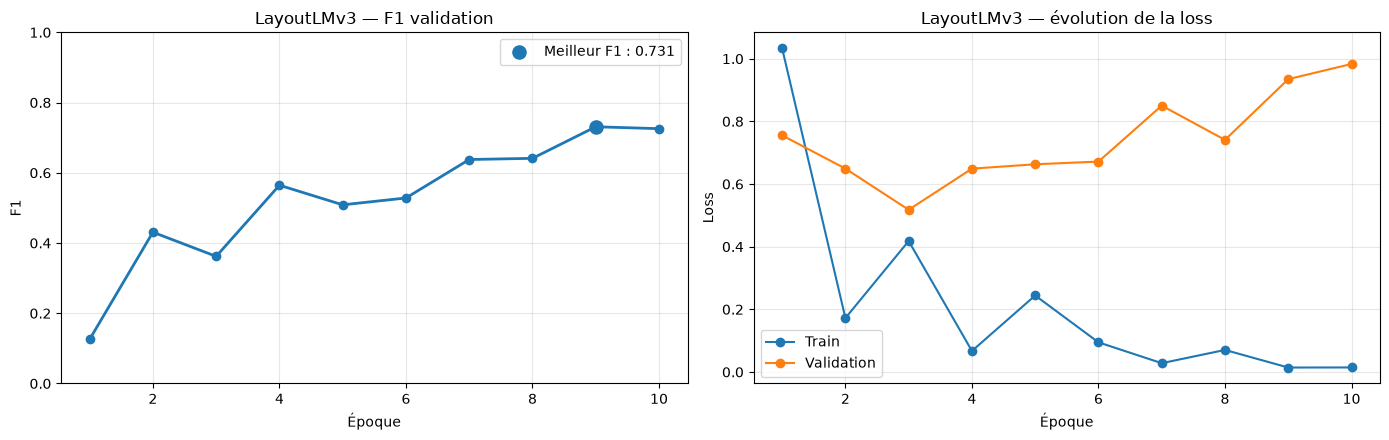

,model,epoch,train_loss,eval_loss,precision,recall,f1,accuracy,learning_rate
8,LayoutLMv3,9.0,0.01426,0.934795,0.625899,0.878788,0.731092,0.983207,0.000005


In [36]:
layout_metrics_path = (
    PROJECT_ROOT
    / "models"
    / "layoutlmv3-hyperparameter"
    / "lr-5e-05-rerun"
    / "training_metrics.csv"
)

print(
    "Historique utilisé :",
    layout_metrics_path.resolve(),
)
print(
    "Fichier présent    :",
    layout_metrics_path.exists(),
)

if layout_metrics_path.exists():
    layout_history = charger_historique_entrainement(layout_metrics_path)
    display(layout_history)
    visualiser_entrainement(layout_history, "LayoutLMv3")
    layout_best_epoch = afficher_meilleure_epoque(layout_history, "LayoutLMv3")
else:
    print("CSV LayoutLMv3 introuvable :", layout_metrics_path)

### Interprétation des courbes

- La **train loss** mesure l'erreur sur les exemples utilisés pour apprendre.
- L'**eval loss** mesure l'erreur sur les exemples de validation non utilisés pour mettre à jour les poids.
- Le **F1-score** combine précision et rappel sur les entités.
- Si la train loss continue de baisser alors que l'eval loss remonte, le modèle commence à **surapprendre**.

Le checkpoint final n'est donc pas forcément celui de la dixième époque : `load_best_model_at_end=True` restaure celui qui a obtenu le meilleur F1 de validation.

## Fine-tuning de LiLT

LiLT exploite le texte et les positions, sans fournir l'image de la page au modèle. Le protocole reste identique afin que la comparaison avec LayoutLMv3 soit équitable.

### Configuration des paramètres LiLT

In [ ]:
MODEL_NAME = "SCUT-DLVCLab/lilt-roberta-en-base"

PROJECT_ROOT = (
    Path.cwd().parent
    if Path.cwd().name == "notebooks"
    else Path.cwd()
)
DATASET_DIR = (PROJECT_ROOT / "dataset"/ "processed"/ "layoutlm_full"/ "dataset")
LABELS_DIR = (PROJECT_ROOT / "dataset"/ "processed"/ "layoutlm_full"/ "labels.json")

OUTPUT_DIR = (
    PROJECT_ROOT
    / "models"
    / "lilt-photovoltaic-full-split-70-15-15-rerun"
)

FINAL_MODEL_DIR = (
    OUTPUT_DIR
    / "final"
)

METRICS_CSV_PATH = (
    OUTPUT_DIR
    / "training_metrics.csv"
)


MAX_LENGTH = 512
TRAIN_RATIO = 0.70
VALIDATION_RATIO = 0.15
TEST_RATIO = 0.15
SEED = 42
EPOCH = NUM_EPOCHS


### Encodage de LiLT

In [6]:


def encode_lilt_example(
    example: dict[str, Any],
    tokenizer,
) -> dict[str, Any]:
    encoding = tokenizer(
        example["tokens"],
        boxes=example["bboxes"],
        word_labels=example["ner_tags"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
    )

    return {
        "input_ids": encoding["input_ids"],
        "attention_mask": encoding["attention_mask"],
        "bbox": encoding["bbox"],
        "labels": encoding["labels"],
    }

def encode_lilt_dataset(
    dataset: Dataset,
    tokenizer,
) -> Dataset:
    return dataset.map(
        lambda example: encode_lilt_example(example, tokenizer),
        remove_columns=dataset.column_names,
        desc="Encodage LiLT",
    )





### Chargement  du modèle, du dataset

In [ ]:
dataset = load_from_disk(
    str(DATASET_DIR)
)

label2id, id2label = load_labels()

print("\n===== Chargement LiLT =====")
print("Nombre de pages dans le dataset :",len(dataset),)
print("Nombre de labels               :",len(label2id),)

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

print("Tokenizer chargé depuis        :",MODEL_NAME,)

model = (
    LiltForTokenClassification
    .from_pretrained(
        MODEL_NAME,
        num_labels=len(label2id),
        label2id=label2id,
        id2label=id2label,
    )
)

print(
    "Modèle chargé                  :",
    model.__class__.__name__,
)
print(
    "Nombre de labels du modèle     :",
    model.config.num_labels,
)
print(
    "Mapping des labels             :",
    model.config.id2label,
)


===== Chargement LiLT =====
Nombre de pages dans le dataset : 214
Nombre de labels               : 11
Tokenizer chargé depuis        : SCUT-DLVCLab/lilt-roberta-en-base


Loading weights: 100%|██████████| 398/398 [00:00<00:00, 20173.45it/s]
[transformers] LiltForTokenClassification LOAD REPORT from: SCUT-DLVCLab/lilt-roberta-en-base
Key                 | Status     | 
--------------------+------------+-
pooler.dense.weight | UNEXPECTED | 
pooler.dense.bias   | UNEXPECTED | 
classifier.bias     | MISSING    | 
classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Modèle chargé                  : LiltForTokenClassification
Nombre de labels du modèle     : 11
Mapping des labels             : {0: 'O', 1: 'B-CLIENT', 2: 'I-CLIENT', 3: 'B-DATE_DEVIS', 4: 'I-DATE_DEVIS', 5: 'B-EMETTEUR_DEVIS', 6: 'I-EMETTEUR_DEVIS', 7: 'B-MONTANT_TOTAL', 8: 'I-MONTANT_TOTAL', 9: 'B-NUMERO_DEVIS', 10: 'I-NUMERO_DEVIS'}


### Split du datset en données de train/test/evaluation (75%/15%/15%)

In [15]:
train_raw, validation_raw, test_raw = (
    split_by_document(
        dataset,
        train_ratio=TRAIN_RATIO,
        validation_ratio=VALIDATION_RATIO,
        test_ratio=TEST_RATIO,
        seed=SEED,
    )
)

print(
    "\n===== Dataset brut LiLT ====="
)
print(
    "Pages train      :",
    len(train_raw),
)
print(
    "Pages validation :",
    len(validation_raw),
)
print(
    "Pages test       :",
    len(test_raw),
)


===== Split par devis =====
Documents train      : 105
Documents validation : 22
Documents test       : 23
Pages train          : 148
Pages validation     : 31
Pages test           : 35

===== Dataset brut LiLT =====
Pages train      : 148
Pages validation : 31
Pages test       : 35


### Encodage des datasets (train/validate/test)

In [16]:
train_dataset = encode_lilt_dataset(
    train_raw,
    tokenizer,
)

validation_dataset = encode_lilt_dataset(
    validation_raw,
    tokenizer,
)

print_encoded_label_distribution(
    train_dataset,
    id2label,
    "train LiLT",
)

print_encoded_label_distribution(
    validation_dataset,
    id2label,
    "validation LiLT",
)

print(
    "\nColonnes train LiLT :",
    train_dataset.column_names,
)
print(
    "Colonnes validation LiLT :",
    validation_dataset.column_names,
)

required_lilt_columns = {
    "input_ids",
    "attention_mask",
    "bbox",
    "labels",
}

for dataset_name, current_dataset in (
    ("train", train_dataset),
    ("validation", validation_dataset),
):
    missing_columns = (
        required_lilt_columns
        - set(current_dataset.column_names)
    )

    if missing_columns:
        raise ValueError(
            f"Colonnes LiLT manquantes dans "
            f"{dataset_name} : "
            f"{sorted(missing_columns)}"
        )

    if "pixel_values" in (
        current_dataset.column_names
    ):
        raise ValueError(
            "LiLT ne doit pas recevoir "
            "pixel_values."
        )

print(
    "\nEncodage texte + positions LiLT validé."
)

Encodage LiLT: 100%|██████████| 31/31 [00:00<00:00, 680.74 examples/s]


===== Distribution des labels après encodage : train LiLT =====
O                         : 27925
B-CLIENT                  : 98
I-CLIENT                  : 58
B-DATE_DEVIS              : 97
I-DATE_DEVIS              : 48
B-EMETTEUR_DEVIS          : 85
I-EMETTEUR_DEVIS          : 89
B-MONTANT_TOTAL           : 68
I-MONTANT_TOTAL           : 85
B-NUMERO_DEVIS            : 95
I-NUMERO_DEVIS            : 14

===== Distribution des labels après encodage : validation LiLT =====
O                         : 5251
B-CLIENT                  : 21
I-CLIENT                  : 9
B-DATE_DEVIS              : 22
I-DATE_DEVIS              : 20
B-EMETTEUR_DEVIS          : 18
I-EMETTEUR_DEVIS          : 20
B-MONTANT_TOTAL           : 15
I-MONTANT_TOTAL           : 21
B-NUMERO_DEVIS            : 21
I-NUMERO_DEVIS            : 1

Colonnes train LiLT : ['input_ids', 'attention_mask', 'bbox', 'labels']
Colonnes validation LiLT : ['input_ids', 'attention_mask', 'bbox', 'labels']

Encodage texte + positions Li

### configuration du process d'entrainement

In [17]:
class_weights = compute_class_weights(
    train_dataset,
    num_labels=len(label2id),
)

print(
    "\n===== Poids des classes LiLT ====="
)

for label_id, weight in enumerate(
    class_weights
):
    print(
        f"{id2label[label_id]:<25} : "
        f"{weight.item():.4f}"
    )

training_args = TrainingArguments(
    output_dir=str(OUTPUT_DIR),

    learning_rate=5e-5,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    num_train_epochs=EPOCH,
    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=5,

    load_best_model_at_end=True,
    metric_for_best_model="eval_f1",
    greater_is_better=True,

    save_total_limit=2,

    seed=SEED,
    data_seed=SEED,
    report_to="none",
)

trainer = WeightedTrainer(
    class_weights=class_weights,
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=validation_dataset,
    compute_metrics=build_compute_metrics(
        id2label
    ),
)

print(
    "\n===== Vérification du Trainer LiLT ====="
)
print(
    "Type du Trainer         :",
    type(trainer).__name__,
)
print(
    "Pages d'entraînement    :",
    len(trainer.train_dataset),
)
print(
    "Pages de validation     :",
    len(trainer.eval_dataset),
)
print(
    "Learning rate           :",
    trainer.args.learning_rate,
)
print(
    "Nombre d'époques        :",
    trainer.args.num_train_epochs,
)
print(
    "Métrique de sélection   :",
    trainer.args.metric_for_best_model,
)
print(
    "Meilleur modèle rechargé:",
    trainer.args.load_best_model_at_end,
)
print(
    "Stratégie d'évaluation  :",
    trainer.args.eval_strategy,
)
print(
    "Stratégie de sauvegarde :",
    trainer.args.save_strategy,
)
print(
    "Dossier de sortie       :",
    trainer.args.output_dir,
)
print(
    "Nombre de poids         :",
    len(trainer.class_weights),
)


===== Poids des classes LiLT =====
O                         : 0.0933
B-CLIENT                  : 26.5881
I-CLIENT                  : 44.9248
B-DATE_DEVIS              : 26.8622
I-DATE_DEVIS              : 54.2841
B-EMETTEUR_DEVIS          : 30.6545
I-EMETTEUR_DEVIS          : 29.2768
B-MONTANT_TOTAL           : 38.3182
I-MONTANT_TOTAL           : 30.6545
B-NUMERO_DEVIS            : 27.4278
I-NUMERO_DEVIS            : 186.1169

===== Vérification du Trainer LiLT =====
Type du Trainer         : WeightedTrainer
Pages d'entraînement    : 148
Pages de validation     : 31
Learning rate           : 5e-05
Nombre d'époques        : 10
Métrique de sélection   : eval_f1
Meilleur modèle rechargé: True
Stratégie d'évaluation  : IntervalStrategy.EPOCH
Stratégie de sauvegarde : SaveStrategy.EPOCH
Dossier de sortie       : /Users/alibahabakar/Projects/document-intelligence-engine/models/lilt-photovoltaic-full-split-70-15-15-rerun
Nombre de poids         : 11


In [18]:

if RUN_LILT_TRAINING:
    print("\n===== Début du fine-tuning LiLT =====")
    train_result = trainer.train()

    epoch_metrics = build_epoch_metrics(
        trainer.state.log_history
    )
    print_metrics_table(epoch_metrics)
    save_metrics_csv(epoch_metrics, METRICS_CSV_PATH)




===== Début du fine-tuning LiLT =====


/Users/alibahabakar/Projects/document-intelligence-engine/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.998779,0.612330,0.073516,0.787879,0.134483,0.796457
2,0.157651,0.741983,0.326360,0.787879,0.461538,0.957557
3,0.126263,0.481430,0.244048,0.828283,0.377011,0.943347
4,0.037541,1.074431,0.469880,0.787879,0.588679,0.978963
5,0.085642,0.837289,0.437838,0.818182,0.570423,0.975826
6,0.015112,1.029515,0.519481,0.808081,0.632411,0.980439
7,0.013190,0.739957,0.474860,0.858586,0.611511,0.977118
8,0.009506,0.931150,0.538961,0.838384,0.656126,0.981731
9,0.009450,1.153177,0.625954,0.828283,0.713043,0.984868
10,0.006058,1.089941,0.627907,0.818182,0.710526,0.985606



===== Distribution des labels réels en validation =====
O                         : 5251
B-CLIENT                  : 21
I-CLIENT                  : 9
B-DATE_DEVIS              : 22
I-DATE_DEVIS              : 20
B-EMETTEUR_DEVIS          : 18
I-EMETTEUR_DEVIS          : 20
B-MONTANT_TOTAL           : 15
I-MONTANT_TOTAL           : 21
B-NUMERO_DEVIS            : 21
I-NUMERO_DEVIS            : 1

===== Distribution des labels prédits en validation =====
O                         : 4187
B-CLIENT                  : 31
I-CLIENT                  : 15
B-DATE_DEVIS              : 71
I-DATE_DEVIS              : 30
B-EMETTEUR_DEVIS          : 291
I-EMETTEUR_DEVIS          : 39
B-MONTANT_TOTAL           : 72
I-MONTANT_TOTAL           : 148
B-NUMERO_DEVIS            : 527
I-NUMERO_DEVIS            : 8


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.20it/s]
/Users/alibahabakar/Projects/document-intelligence-engine/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


...


===== Distribution des labels réels en validation =====
O                         : 5251
B-CLIENT                  : 21
I-CLIENT                  : 9
B-DATE_DEVIS              : 22
I-DATE_DEVIS              : 20
B-EMETTEUR_DEVIS          : 18
I-EMETTEUR_DEVIS          : 20
B-MONTANT_TOTAL           : 15
I-MONTANT_TOTAL           : 21
B-NUMERO_DEVIS            : 21
I-NUMERO_DEVIS            : 1

===== Distribution des labels prédits en validation =====
O                         : 5215
B-CLIENT                  : 21
I-CLIENT                  : 12
B-DATE_DEVIS              : 34
I-DATE_DEVIS              : 23
B-EMETTEUR_DEVIS          : 20
I-EMETTEUR_DEVIS          : 27
B-MONTANT_TOTAL           : 14
I-MONTANT_TOTAL           : 19
B-NUMERO_DEVIS            : 33
I-NUMERO_DEVIS            : 1


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.49it/s]
/Users/alibahabakar/Projects/document-intelligence-engine/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)



===== Distribution des labels réels en validation =====
O                         : 5251
B-CLIENT                  : 21
I-CLIENT                  : 9
B-DATE_DEVIS              : 22
I-DATE_DEVIS              : 20
B-EMETTEUR_DEVIS          : 18
I-EMETTEUR_DEVIS          : 20
B-MONTANT_TOTAL           : 15
I-MONTANT_TOTAL           : 21
B-NUMERO_DEVIS            : 21
I-NUMERO_DEVIS            : 1

===== Distribution des labels prédits en validation =====
O                         : 5220
B-CLIENT                  : 21
I-CLIENT                  : 12
B-DATE_DEVIS              : 31
I-DATE_DEVIS              : 23
B-EMETTEUR_DEVIS          : 20
I-EMETTEUR_DEVIS          : 23
B-MONTANT_TOTAL           : 14
I-MONTANT_TOTAL           : 19
B-NUMERO_DEVIS            : 35
I-NUMERO_DEVIS            : 1


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.33it/s]



===== Tableau récapitulatif des métriques =====
  Epoch |   Train loss |   Eval loss |   Precision |    Recall |        F1 |   Accuracy |  Learning rate
--------+--------------+-------------+-------------+-----------+-----------+------------+---------------
      1 |       0.9988 |      0.6123 |      0.0735 |    0.7879 |    0.1345 |     0.7965 |       4.53e-05
      2 |       0.1577 |      0.7420 |      0.3264 |    0.7879 |    0.4615 |     0.9576 |       4.03e-05
      3 |       0.1263 |      0.4814 |      0.2440 |    0.8283 |    0.3770 |     0.9433 |       3.52e-05
      4 |       0.0375 |      1.0744 |      0.4699 |    0.7879 |    0.5887 |     0.9790 |       3.01e-05
      5 |       0.0856 |      0.8373 |      0.4378 |    0.8182 |    0.5704 |     0.9758 |       2.51e-05
      6 |       0.0151 |      1.0295 |      0.5195 |    0.8081 |    0.6324 |     0.9804 |       2.03e-05
      7 |       0.0132 |      0.7400 |      0.4749 |    0.8586 |    0.6115 |     0.9771 |       1.53e-05
      

### Sélection et sauvegarde du meilleur modèle LiLT

In [ ]:
if RUN_LILT_TRAINING:
    if not epoch_metrics:
        raise ValueError(
            "Aucune métrique de validation LiLT "
            "n'a été enregistrée."
        )

    # Les métriques ont déjà été calculées pendant trainer.train()
    best_epoch_metrics = max(
        epoch_metrics,
        key=lambda row: row["f1"],
    )

    print(
        "\n===== Meilleur checkpoint LiLT ====="
    )
    print(
        "Meilleure époque :",
        int(best_epoch_metrics["epoch"]),
    )
    print(
        "Meilleur F1      :",
        f"{best_epoch_metrics['f1']:.4f}",
    )
    print(
        "Best metric      :",
        trainer.state.best_metric,
    )
    print(
        "Best checkpoint  :",
        trainer.state.best_model_checkpoint,
    )

    best_lilt_checkpoint = Path(
        trainer.state.best_model_checkpoint
    )

    print(
        "Checkpoint présent :",
        best_lilt_checkpoint.exists(),
    )

    # Le meilleur checkpoint est déjà chargé grâce à :
    # load_best_model_at_end=True
    FINAL_MODEL_DIR.mkdir(
        parents=True,
        exist_ok=True,
    )

    trainer.save_model(
        str(FINAL_MODEL_DIR)
    )
    tokenizer.save_pretrained(
        str(FINAL_MODEL_DIR)
    )

    model_weights_path = (
        FINAL_MODEL_DIR
        / "model.safetensors"
    )

    if not model_weights_path.exists():
        raise FileNotFoundError(
            "Le fichier model.safetensors "
            "de LiLT n'a pas été sauvegardé."
        )

    print(
        "\n===== Fine-tuning LiLT terminé ====="
    )
    print(
        "Modèle sauvegardé dans :",
        FINAL_MODEL_DIR,
    )

else:
    print(
        "\nEntraînement LiLT désactivé : "
        "aucun modèle sauvegardé."
    )


===== Évaluation finale sur la validation =====


/Users/alibahabakar/Projects/document-intelligence-engine/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)



===== Distribution des labels réels en validation =====
O                         : 5251
B-CLIENT                  : 21
I-CLIENT                  : 9
B-DATE_DEVIS              : 22
I-DATE_DEVIS              : 20
B-EMETTEUR_DEVIS          : 18
I-EMETTEUR_DEVIS          : 20
B-MONTANT_TOTAL           : 15
I-MONTANT_TOTAL           : 21
B-NUMERO_DEVIS            : 21
I-NUMERO_DEVIS            : 1

===== Distribution des labels prédits en validation =====
O                         : 5215
B-CLIENT                  : 21
I-CLIENT                  : 12
B-DATE_DEVIS              : 34
I-DATE_DEVIS              : 23
B-EMETTEUR_DEVIS          : 20
I-EMETTEUR_DEVIS          : 27
B-MONTANT_TOTAL           : 14
I-MONTANT_TOTAL           : 19
B-NUMERO_DEVIS            : 33
I-NUMERO_DEVIS            : 1


Training Loss,Validation Loss,Epoch,Precision,Recall,F1,Accuracy
0.006058,1.153177,10,0.625954,0.828283,0.713043,0.984868


eval_loss                      : 1.1532
eval_precision                 : 0.6260
eval_recall                    : 0.8283
eval_f1                        : 0.7130
eval_accuracy                  : 0.9849


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.04it/s]


===== Fine-tuning LiLT terminé =====
Modèle sauvegardé dans : /Users/alibahabakar/Projects/document-intelligence-engine/models/lilt-photovoltaic-full-split-70-15-15-rerun/final


### Visualisation des résultats LiLT

In [21]:
lilt_final_weights = (
    FINAL_MODEL_DIR
    / "model.safetensors"
)

print(
    "\n===== Vérification du modèle LiLT final ====="
)
print(
    "Dossier final :",
    FINAL_MODEL_DIR.resolve(),
)
print(
    "Dossier présent :",
    FINAL_MODEL_DIR.exists(),
)
print(
    "Poids présents :",
    lilt_final_weights.exists(),
)

if not lilt_final_weights.exists():
    raise FileNotFoundError(
        "Le fichier model.safetensors "
        "de LiLT est introuvable."
    )

lilt_weights_size_mb = (
    lilt_final_weights.stat().st_size
    / (1024 * 1024)
)

print(
    f"Taille des poids : "
    f"{lilt_weights_size_mb:.2f} Mo"
)

reloaded_lilt_model = (
    LiltForTokenClassification
    .from_pretrained(FINAL_MODEL_DIR)
)

reloaded_lilt_tokenizer = (
    AutoTokenizer.from_pretrained(
        FINAL_MODEL_DIR
    )
)

print(
    "Rechargement du modèle : réussi"
)
print(
    "Rechargement du tokenizer : réussi"
)
print(
    "Nombre de labels :",
    reloaded_lilt_model.config.num_labels,
)
print(
    "Mapping des labels :",
    reloaded_lilt_model.config.id2label,
)


===== Vérification du modèle LiLT final =====
Dossier final : /Users/alibahabakar/Projects/document-intelligence-engine/models/lilt-photovoltaic-full-split-70-15-15-rerun/final
Dossier présent : True
Poids présents : True
Taille des poids : 496.62 Mo


Loading weights: 100%|██████████| 400/400 [00:00<00:00, 6905.97it/s]

Rechargement du modèle : réussi
Rechargement du tokenizer : réussi
Nombre de labels : 11
Mapping des labels : {0: 'O', 1: 'B-CLIENT', 2: 'I-CLIENT', 3: 'B-DATE_DEVIS', 4: 'I-DATE_DEVIS', 5: 'B-EMETTEUR_DEVIS', 6: 'I-EMETTEUR_DEVIS', 7: 'B-MONTANT_TOTAL', 8: 'I-MONTANT_TOTAL', 9: 'B-NUMERO_DEVIS', 10: 'I-NUMERO_DEVIS'}


Historique LiLT utilisé : /Users/alibahabakar/Projects/document-intelligence-engine/models/lilt-photovoltaic-full-split-70-15-15-rerun/training_metrics.csv
Fichier présent         : True


,epoch,train_loss,eval_loss,precision,recall,f1,accuracy,learning_rate
0,1.0,0.998779,0.612330,0.073516,0.787879,0.134483,0.796457,4.533784e-05
1,2.0,0.157651,0.741983,0.326360,0.787879,0.461538,0.957557,4.027027e-05
2,3.0,0.126263,0.481430,0.244048,0.828283,0.377011,0.943347,3.520270e-05
3,4.0,0.037541,1.074431,0.469880,0.787879,0.588679,0.978963,3.013514e-05
4,5.0,0.085642,0.837289,0.437838,0.818182,0.570423,0.975826,2.506757e-05
5,6.0,0.015112,1.029515,0.519481,0.808081,0.632411,0.980439,2.033784e-05
6,7.0,0.013190,0.739957,0.474860,0.858586,0.611511,0.977118,1.527027e-05
7,8.0,0.009506,0.931150,0.538961,0.838384,0.656126,0.981731,1.020270e-05
8,9.0,0.009450,1.153177,0.625954,0.828283,0.713043,0.984868,5.135135e-06
9,10.0,0.006058,1.089941,0.627907,0.818182,0.710526,0.985606,6.756757e-08


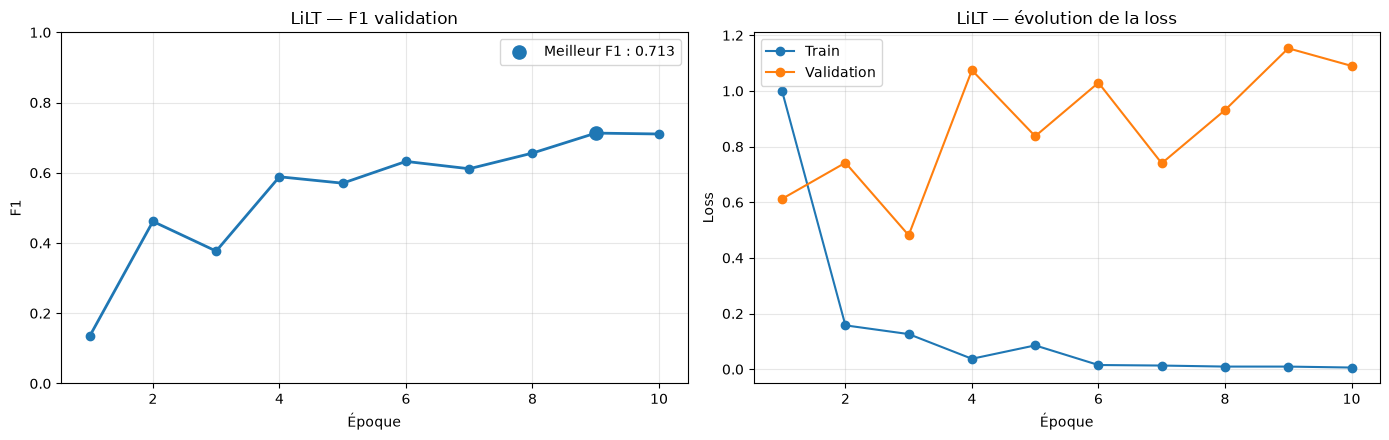

,model,epoch,train_loss,eval_loss,precision,recall,f1,accuracy,learning_rate
8,LiLT,9.0,0.00945,1.153177,0.625954,0.828283,0.713043,0.984868,0.000005


In [28]:
lilt_metrics_path = (
    PROJECT_ROOT
    / "models"
    / "lilt-photovoltaic-full-split-70-15-15-rerun"
    / "training_metrics.csv"
)

print(
    "Historique LiLT utilisé :",
    lilt_metrics_path.resolve(),
)
print(
    "Fichier présent         :",
    lilt_metrics_path.exists(),
)

if lilt_metrics_path.exists():
    lilt_history = (
        charger_historique_entrainement(
            lilt_metrics_path
        )
    )

    display(lilt_history)

    visualiser_entrainement(
        lilt_history,
        "LiLT",
    )

    lilt_best_epoch = (
        afficher_meilleure_epoque(
            lilt_history,
            "LiLT",
        )
    )

else:
    print(
        "CSV LiLT introuvable :",
        lilt_metrics_path.resolve(),
    )

## Évaluation finale sur le jeu de test

Cette partie intervient **après** le choix des configurations et des checkpoints. Elle ne modifie plus les poids : elle mesure uniquement la généralisation sur les 23 documents / 35 pages de test.

### Évaluation finale de LayoutLMv3

In [ ]:
PROJECT_ROOT = (
    Path.cwd().parent
    if Path.cwd().name == "notebooks"
    else Path.cwd()
)

DATASET_DIR = (
    PROJECT_ROOT
    / "dataset"
    / "processed"
    / "layoutlm_full"
    / "dataset"
)

LABELS_DIR = (
    PROJECT_ROOT
    / "dataset"
    / "processed"
    / "layoutlm_full"
    / "labels.json"
)

MODEL_DIR = (
    PROJECT_ROOT
    / "models"
    / "layoutlmv3-hyperparameter"
    / "lr-5e-05-rerun"
    / "final"
)

OUTPUT_DIR = (
    PROJECT_ROOT
    / "models"
    / "layoutlmv3-hyperparameter"
    / "lr-5e-05-rerun"
    / "test-evaluation"
)

TEST_METRICS_PATH = (
    OUTPUT_DIR
    / "test_metrics.json"
)

MAX_LENGTH = 512
TRAIN_RATIO = 0.70
VALIDATION_RATIO = 0.15
TEST_RATIO = 0.15
SEED = 42

print(
    "Modèle LayoutLMv3 :",
    MODEL_DIR.resolve(),
)
print(
    "Modèle présent     :",
    MODEL_DIR.exists(),
)
print(
    "Sortie du test     :",
    OUTPUT_DIR.resolve(),
)

In [ ]:
#if RUN_FINAL_TEST_EVALUATION:
OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

_, id2label = load_labels()

dataset = load_from_disk(
    str(DATASET_DIR)
)

# 2 - Récupérer les dataset de test non utilisés pendant l'entrainement
_, _, test_raw = split_by_document(
    dataset,
    train_ratio=TRAIN_RATIO,
    validation_ratio=VALIDATION_RATIO,
    test_ratio=TEST_RATIO,
    seed=SEED,
)

# 3 - Charger 
processor = AutoProcessor.from_pretrained(
    MODEL_DIR,
    apply_ocr=False,
)

model = (
    LayoutLMv3ForTokenClassification.from_pretrained(
        MODEL_DIR
    )
)

   


===== Split par devis =====
Documents train      : 105
Documents validation : 22
Documents test       : 23
Pages train          : 148
Pages validation     : 31
Pages test           : 35


Loading weights: 100%|██████████| 216/216 [00:00<00:00, 8130.10it/s]


### Encodage du modèle fine tuné sur les données de test

In [ ]:
 # Encoder le jeu de test
test_dataset = encode_layoutlmv3_dataset(
    test_raw,
    processor,
)

evaluation_args = TrainingArguments(
    output_dir=str(OUTPUT_DIR),
    per_device_eval_batch_size=2,
    report_to="none",
    seed=SEED,
    data_seed=SEED,
)

trainer = Trainer(
    model=model,
    args=evaluation_args,
    compute_metrics=build_compute_metrics(
        id2label
    ),
)

print(
    "\n===== Évaluation finale LayoutLMv3 "
    "sur le test ====="
)



Encodage: 100%|██████████| 35/35 [00:00<00:00, 78.25 examples/s]



===== Évaluation finale LayoutLMv3 sur le test =====


/Users/alibahabakar/Projects/document-intelligence-engine/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)



===== Distribution des labels réels en validation =====
O                         : 6928
B-CLIENT                  : 21
I-CLIENT                  : 14
B-DATE_DEVIS              : 21
I-DATE_DEVIS              : 11
B-EMETTEUR_DEVIS          : 20
I-EMETTEUR_DEVIS          : 17
B-MONTANT_TOTAL           : 16
I-MONTANT_TOTAL           : 16
B-NUMERO_DEVIS            : 19
I-NUMERO_DEVIS            : 9

===== Distribution des labels prédits en validation =====
O                         : 3219
B-CLIENT                  : 764
I-CLIENT                  : 25
B-DATE_DEVIS              : 0
I-DATE_DEVIS              : 249
B-EMETTEUR_DEVIS          : 580
I-EMETTEUR_DEVIS          : 1073
B-MONTANT_TOTAL           : 18
I-MONTANT_TOTAL           : 289
B-NUMERO_DEVIS            : 146
I-NUMERO_DEVIS            : 729


Training Loss,Validation Loss,Step,Precision,Recall,F1,Accuracy
No log,2.207665,0,0.001284,0.040816,0.002489,0.448111



===== Métriques finales du test =====
test_loss                      : 2.2077
test_precision                 : 0.0013
test_recall                    : 0.0408
test_f1                        : 0.0025
test_accuracy                  : 0.4481

Métriques sauvegardées dans : models/layoutlmv3-hyperparameter/lr-5e-05/test-evaluation/test_metrics.json


### Evaluation du modèle fine tuné

In [64]:
# Prédire sans changer les poids - juste de l'inférence
test_metrics = trainer.evaluate(
    eval_dataset=test_dataset,
    metric_key_prefix="test",
)

print(
    "\n===== Métriques finales du test ====="
)

for metric_name, metric_value in test_metrics.items():
    if isinstance(metric_value, float):
        print(
            f"{metric_name:<30} : "
            f"{metric_value:.4f}"
        )
    else:
        print(
            f"{metric_name:<30} : "
            f"{metric_value}"
        )

serializable_metrics = {
    key: float(value)
    if isinstance(value, (int, float))
    else value
    for key, value in test_metrics.items()
}

with TEST_METRICS_PATH.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        serializable_metrics,
        file,
        ensure_ascii=False,
        indent=2,
    )

print(
    "\nMétriques sauvegardées dans :",
    TEST_METRICS_PATH,
)



===== Distribution des labels réels en validation =====
O                         : 6928
B-CLIENT                  : 21
I-CLIENT                  : 14
B-DATE_DEVIS              : 21
I-DATE_DEVIS              : 11
B-EMETTEUR_DEVIS          : 20
I-EMETTEUR_DEVIS          : 17
B-MONTANT_TOTAL           : 16
I-MONTANT_TOTAL           : 16
B-NUMERO_DEVIS            : 19
I-NUMERO_DEVIS            : 9

===== Distribution des labels prédits en validation =====
O                         : 3219
B-CLIENT                  : 764
I-CLIENT                  : 25
B-DATE_DEVIS              : 0
I-DATE_DEVIS              : 249
B-EMETTEUR_DEVIS          : 580
I-EMETTEUR_DEVIS          : 1073
B-MONTANT_TOTAL           : 18
I-MONTANT_TOTAL           : 289
B-NUMERO_DEVIS            : 146
I-NUMERO_DEVIS            : 729


Training Loss,Validation Loss,Step,Precision,Recall,F1,Accuracy
No log,2.207665,0,0.001284,0.040816,0.002489,0.448111



===== Métriques finales du test =====
test_loss                      : 2.2077
test_precision                 : 0.0013
test_recall                    : 0.0408
test_f1                        : 0.0025
test_accuracy                  : 0.4481

Métriques sauvegardées dans : models/layoutlmv3-hyperparameter/lr-5e-05/test-evaluation/test_metrics.json


### Évaluation finale de LiLT

In [ ]:
PROJECT_ROOT = (
    Path.cwd().parent
    if Path.cwd().name == "notebooks"
    else Path.cwd()
)

DATASET_DIR = (
    PROJECT_ROOT
    / "dataset"
    / "processed"
    / "layoutlm_full"
    / "dataset"
)

LABELS_DIR = (
    PROJECT_ROOT
    / "dataset"
    / "processed"
    / "layoutlm_full"
    / "labels.json"
)

MODEL_DIR = (
    PROJECT_ROOT
    / "models"
    / "lilt-photovoltaic-full-split-70-15-15-rerun"
    / "final"
)

OUTPUT_DIR = (
    PROJECT_ROOT
    / "models"
    / "lilt-photovoltaic-full-split-70-15-15-rerun"
    / "test-evaluation"
)

TEST_METRICS_PATH = (
    OUTPUT_DIR
    / "test_metrics.json"
)

MAX_LENGTH = 512
TRAIN_RATIO = 0.70
VALIDATION_RATIO = 0.15
TEST_RATIO = 0.15
SEED = 42

print("Dataset :", DATASET_DIR.resolve())
print("Dataset présent :", DATASET_DIR.exists())

print("\nLabels :", LABELS_DIR.resolve())
print("Labels présents :", LABELS_DIR.exists())

print("\nModèle LiLT :", MODEL_DIR.resolve())
print("Modèle présent :", MODEL_DIR.exists())

print(
    "Poids présents :",
    (
        MODEL_DIR
        / "model.safetensors"
    ).exists(),
)

print(
    "Dossier de sortie :",
    OUTPUT_DIR.resolve(),
)

### Chargement du modèle fine tuné et encodage

In [31]:
OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

label2id_test, id2label_test = (
    load_labels()
)

lilt_test_raw_dataset = load_from_disk(
    str(DATASET_DIR)
)

_, _, lilt_test_raw = split_by_document(
    lilt_test_raw_dataset,
    train_ratio=TRAIN_RATIO,
    validation_ratio=VALIDATION_RATIO,
    test_ratio=TEST_RATIO,
    seed=SEED,
)

lilt_test_tokenizer = (
    AutoTokenizer.from_pretrained(
        MODEL_DIR
    )
)

lilt_test_model = (
    LiltForTokenClassification
    .from_pretrained(MODEL_DIR)
)

model_id2label = {
    int(label_id): label
    for label_id, label
    in lilt_test_model.config.id2label.items()
}

if model_id2label != id2label_test:
    raise ValueError(
        "Le mapping LiLT ne correspond "
        "pas au dataset."
    )

lilt_test_dataset = encode_lilt_dataset(
    lilt_test_raw,
    lilt_test_tokenizer,
)

required_columns = {
    "input_ids",
    "attention_mask",
    "bbox",
    "labels",
}

missing_columns = (
    required_columns
    - set(lilt_test_dataset.column_names)
)

if missing_columns:
    raise ValueError(
        "Colonnes LiLT manquantes : "
        f"{sorted(missing_columns)}"
    )

if "pixel_values" in (
    lilt_test_dataset.column_names
):
    raise ValueError(
        "LiLT ne doit pas recevoir "
        "pixel_values."
    )

print(
    "\n===== Préparation du test LiLT ====="
)
print(
    "Documents de test :",
    len({
        example["id"].rsplit(
            "_page_",
            1,
        )[0]
        for example in lilt_test_raw
    }),
)
print(
    "Pages de test     :",
    len(lilt_test_dataset),
)
print(
    "Colonnes          :",
    lilt_test_dataset.column_names,
)
print(
    "Nombre de labels  :",
    lilt_test_model.config.num_labels,
)
print(
    "Mapping validé    :",
    model_id2label == id2label_test,
)
print(
    "Modèle chargé depuis :",
    MODEL_DIR.resolve(),
)


===== Split par devis =====
Documents train      : 105
Documents validation : 22
Documents test       : 23
Pages train          : 148
Pages validation     : 31
Pages test           : 35


Loading weights: 100%|██████████| 400/400 [00:00<00:00, 20672.29it/s]



===== Préparation du test LiLT =====
Documents de test : 23
Pages de test     : 35
Colonnes          : ['input_ids', 'attention_mask', 'bbox', 'labels']
Nombre de labels  : 11
Mapping validé    : True
Modèle chargé depuis : /Users/alibahabakar/Projects/document-intelligence-engine/models/lilt-photovoltaic-full-split-70-15-15-rerun/final


### Chargement et évaluation de LiLT sur le jeu de test

In [33]:
lilt_test_args = TrainingArguments(
    output_dir=str(OUTPUT_DIR),
    per_device_eval_batch_size=2,
    report_to="none",
    seed=SEED,
    data_seed=SEED,
)

lilt_test_trainer = Trainer(
    model=lilt_test_model,
    args=lilt_test_args,
    compute_metrics=build_compute_metrics(
        id2label_test
    ),
)

print(
    "\n===== Évaluation finale LiLT "
    "sur le jeu de test ====="
)

lilt_test_metrics = (
    lilt_test_trainer.evaluate(
        eval_dataset=lilt_test_dataset,
        metric_key_prefix="test",
    )
)

print(
    "\n===== Métriques finales LiLT "
    "sur le test ====="
)

metric_names = (
    "test_loss",
    "test_precision",
    "test_recall",
    "test_f1",
    "test_accuracy",
    "test_runtime",
)

for metric_name in metric_names:
    if metric_name not in lilt_test_metrics:
        continue

    print(
        f"{metric_name:<30} : "
        f"{float(lilt_test_metrics[metric_name]):.4f}"
    )

serializable_metrics = {
    key: float(value)
    if isinstance(
        value,
        (
            int,
            float,
            np.integer,
            np.floating,
        ),
    )
    else value
    for key, value
    in lilt_test_metrics.items()
}

with TEST_METRICS_PATH.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        serializable_metrics,
        file,
        ensure_ascii=False,
        indent=2,
    )

print(
    "\nMétriques sauvegardées dans :",
    TEST_METRICS_PATH.resolve(),
)


===== Évaluation finale LiLT sur le jeu de test =====


/Users/alibahabakar/Projects/document-intelligence-engine/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)



===== Distribution des labels réels en validation =====
O                         : 6928
B-CLIENT                  : 21
I-CLIENT                  : 14
B-DATE_DEVIS              : 21
I-DATE_DEVIS              : 11
B-EMETTEUR_DEVIS          : 20
I-EMETTEUR_DEVIS          : 17
B-MONTANT_TOTAL           : 16
I-MONTANT_TOTAL           : 16
B-NUMERO_DEVIS            : 19
I-NUMERO_DEVIS            : 9

===== Distribution des labels prédits en validation =====
O                         : 6884
B-CLIENT                  : 27
I-CLIENT                  : 18
B-DATE_DEVIS              : 40
I-DATE_DEVIS              : 18
B-EMETTEUR_DEVIS          : 24
I-EMETTEUR_DEVIS          : 21
B-MONTANT_TOTAL           : 14
I-MONTANT_TOTAL           : 14
B-NUMERO_DEVIS            : 29
I-NUMERO_DEVIS            : 3


Training Loss,Validation Loss,Step,Precision,Recall,F1,Accuracy
No log,0.112426,0,0.525180,0.744898,0.616034,0.982657



===== Métriques finales LiLT sur le test =====
test_loss                      : 0.1124
test_precision                 : 0.5252
test_recall                    : 0.7449
test_f1                        : 0.6160
test_accuracy                  : 0.9827

Métriques sauvegardées dans : /Users/alibahabakar/Projects/document-intelligence-engine/models/lilt-photovoltaic-full-split-70-15-15-rerun/test-evaluation/test_metrics.json


## Comparaison finale des deux modèles

Le F1-score est la métrique principale, car le dataset est déséquilibré

Fichier LayoutLMv3 : /Users/alibahabakar/Projects/document-intelligence-engine/models/layoutlmv3-hyperparameter/lr-5e-05-rerun/test-evaluation/test_metrics.json
Fichier présent    : True

Fichier LiLT : /Users/alibahabakar/Projects/document-intelligence-engine/models/lilt-photovoltaic-full-split-70-15-15-rerun/test-evaluation/test_metrics.json
Fichier présent : True

Clés LayoutLMv3 : dict_keys(['test_loss', 'test_precision', 'test_recall', 'test_f1', 'test_accuracy'])
Clés LiLT       : dict_keys(['test_loss', 'test_precision', 'test_recall', 'test_f1', 'test_accuracy'])

===== Comparaison finale sur le test =====


,Précision,Rappel,F1,Accuracy
Modèle,,,,
LayoutLMv3,58.16%,83.67%,68.62%,98.35%
LiLT,52.52%,74.49%,61.60%,98.27%


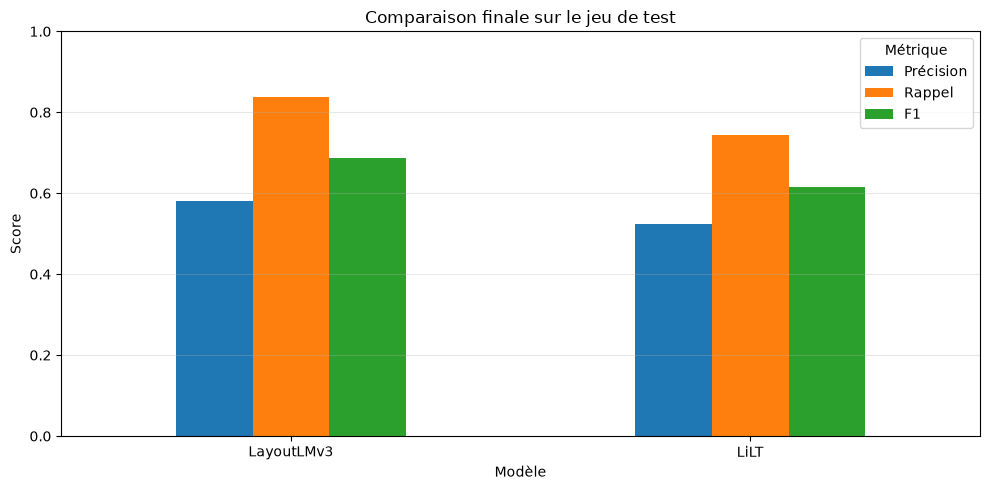


===== Écart LayoutLMv3 - LiLT =====
Précision    : +5.64 points
Rappel       : +9.18 points
F1           : +7.02 points
Accuracy     : +0.08 points


In [34]:
layout_test_path = (
    PROJECT_ROOT
    / "models"
    / "layoutlmv3-hyperparameter"
    / "lr-5e-05-rerun"
    / "test-evaluation"
    / "test_metrics.json"
)

lilt_test_path = (
    PROJECT_ROOT
    / "models"
    / "lilt-photovoltaic-full-split-70-15-15-rerun"
    / "test-evaluation"
    / "test_metrics.json"
)

print(
    "Fichier LayoutLMv3 :",
    layout_test_path.resolve(),
)
print(
    "Fichier présent    :",
    layout_test_path.exists(),
)

print(
    "\nFichier LiLT :",
    lilt_test_path.resolve(),
)
print(
    "Fichier présent :",
    lilt_test_path.exists(),
)

if (
    layout_test_path.exists()
    and lilt_test_path.exists()
):
    layout_test = json.loads(
        layout_test_path.read_text(
            encoding="utf-8"
        )
    )

    lilt_test = json.loads(
        lilt_test_path.read_text(
            encoding="utf-8"
        )
    )

    print(
        "\nClés LayoutLMv3 :",
        layout_test.keys(),
    )
    print(
        "Clés LiLT       :",
        lilt_test.keys(),
    )

    comparison = pd.DataFrame(
        [
            {
                "Modèle": "LayoutLMv3",
                "Précision": layout_test[
                    "test_precision"
                ],
                "Rappel": layout_test[
                    "test_recall"
                ],
                "F1": layout_test[
                    "test_f1"
                ],
                "Accuracy": layout_test[
                    "test_accuracy"
                ],
            },
            {
                "Modèle": "LiLT",
                "Précision": lilt_test[
                    "test_precision"
                ],
                "Rappel": lilt_test[
                    "test_recall"
                ],
                "F1": lilt_test[
                    "test_f1"
                ],
                "Accuracy": lilt_test[
                    "test_accuracy"
                ],
            },
        ]
    ).set_index("Modèle")

    print(
        "\n===== Comparaison finale sur le test ====="
    )

    display(
        comparison.style.format(
            {
                "Précision": "{:.2%}",
                "Rappel": "{:.2%}",
                "F1": "{:.2%}",
                "Accuracy": "{:.2%}",
            }
        )
    )

    comparison[
        [
            "Précision",
            "Rappel",
            "F1",
        ]
    ].plot(
        kind="bar",
        figsize=(10, 5),
        ylim=(0, 1),
        rot=0,
        title=(
            "Comparaison finale "
            "sur le jeu de test"
        ),
    )

    plt.ylabel("Score")
    plt.xlabel("Modèle")
    plt.grid(
        axis="y",
        alpha=0.3,
    )
    plt.legend(
        title="Métrique"
    )
    plt.tight_layout()
    plt.show()

    comparison_difference = (
        comparison.loc["LayoutLMv3"]
        - comparison.loc["LiLT"]
    )

    print(
        "\n===== Écart LayoutLMv3 - LiLT ====="
    )

    for metric_name, difference in (
        comparison_difference.items()
    ):
        print(
            f"{metric_name:<12} : "
            f"{difference * 100:+.2f} points"
        )

else:
    print(
        "\nLes deux fichiers de métriques "
        "de test ne sont pas disponibles."
    )

## Conclusion

Résultats finaux obtenus dans le projet :

| Modèle | Précision | Rappel | F1-score | Accuracy |
|---|---:|---:|---:|---:|
| **LayoutLMv3** | **58,16 %** | **83,67 %** | **68,62 %** | **98,35 %** |
| LiLT | 52,52 % | 74,49 % | 61,60 % | 98,27 % |

**LayoutLMv3 est retenu comme modèle de référence**, car il obtient le meilleur F1-score et le meilleur rappel sur le jeu de test indépendant. Son F1-score est supérieur de 7,02 points à celui de LiLT et son rappel est supérieur de 9,18 points.

L’accuracy dépasse 98 % pour les deux modèles, mais elle doit être interprétée avec prudence, car la majorité des tokens appartiennent à la classe `O`. Le F1-score constitue donc la métrique principale pour comparer la qualité d’extraction.

LayoutLMv3 exploite le texte, les positions et l’image de la page, tandis que LiLT utilise le texte et les positions. Les résultats suggèrent que la composante visuelle de LayoutLMv3 apporte une information utile pour comprendre les devis. La qualité d’extraction reste prioritaire pour le cas d’usage Beluo.

### Limites

- dataset limité à 150 devis annotés ;
- jeu de test limité à 23 devis, soit 35 pages ;
- dépendance à la qualité du texte et des coordonnées produits par l’OCR ;
- diversité des fournisseurs et des mises en page encore limitée ;
- surapprentissage ou mauvaise calibration observé pendant le fine-tuning ;
- forte pondération de certaines classes très rares ;
- analyse des performances par entité métier à approfondir.